In [1]:
from copy import deepcopy

from typing import Self
from typing import Iterator


import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout

In [2]:
class Node:
    def __init__(self, data, id: int | None = None):
        self.data = data
        self.right: Node | None = None
        self.left: Node | None = None
        self.id: int | None = id

    def __repr__(self) -> str:
        return f"{'+' if self.left is not None else '-'}:{self.data}:{'+' if self.right is not None else '-'}"

    def __str__(self) -> str:
        return repr(self)

    def __len__(self) -> None:
        return sum([self.left is not None, self.right is not None])

    def __lt__(self, other: Self) -> bool:
        return self.data < other.data

    def __le__(self, other: Self) -> bool:
        return self.data <= other.data

    def __eq__(self, other: Self) -> bool:
        return self.data == other.data

In [3]:
class TreeIterator:
    def __init__(self, root: Node) -> None:
        self.stack = []
        self.fill(node=root)

    def fill(self, node: Node):
        def go(node: None) -> None:
            self.stack.append(node)
            if node.left is not None:
                go(node=node.left)
            if node.right is not None:
                go(node=node.right)

        go(node=node)

    def __iter__(self):
        return self

    def __next__(self):
        if len(self.stack) == 0:
            raise StopIteration

        node = self.stack.pop()

        return node

In [4]:
class Tree:
    def __init__(self):
        self.root = None
        self.counter = 0

    def is_valid(self) -> bool:
        stack = [(self.root, None)]
        while len(stack) > 0:
            node, parent = stack.pop()

            if len(node) == 0:
                continue

            if node.left is not None:
                if node.left < node:
                    if parent is not None:
                        if parent < node:
                            if node.left < parent:
                                return False

                    stack.append((node.left, node))

                else:
                    return False

            if node.right is not None:
                if node <= node.right:
                    if parent is not None:
                        if node < parent:
                            if parent < node:
                                return False
                    stack.append((node.right, node))
                else:
                    return False

        return True

    def iter(self) -> Iterator[Node]:
        return TreeIterator(root=self.root)

    def insert(self, data):
        self.counter += 1
        node = Node(data, id=self.counter)
        if self.root is None:
            self.root = node
            return self.root
        else:
            current = self.root
            parent = None
            while True:
                parent = current
                if node.data < parent.data:
                    current = current.left
                    if current is None:
                        parent.left = node
                        return self.root
                else:
                    current = current.right
                    if current is None:
                        parent.right = node
                        return self.root

    def inorder(self, node: Node | None = None):
        if node is None:
            assert self.root is not None
            node = self.root
        if node.left is not None:
            self.inorder(node=node.left)
        print(node.data)
        if node.right is not None:
            self.inorder(node=node.right)

    def get_node_with_parent(self, data):
        parent = None
        current = self.root
        if current is None:
            return (parent, None)
        while True:
            if current.data == data:
                return (parent, current)
            elif current.data > data:
                parent = current
                current = current.left
            else:
                parent = current
                current = current.right
        return (parent, current)

    def remove(self, data):
        parent, node = self.get_node_with_parent(data)

        if parent is None and node is None:
            return False

        # Get children count
        children_count = 0

        if node.left and node.right:
            children_count = 2
        elif (node.left is None) and (node.right is None):
            children_count = 0
        else:
            children_count = 1

        if children_count == 0:
            if parent:
                if parent.right is node:
                    parent.right = None
                else:
                    parent.left = None
            else:
                self.root = None
        elif children_count == 1:
            next_node = None
            if node.left:
                next_node = node.left
            else:
                next_node = node.right

            if parent:
                if parent.left is node:
                    parent.left = next_node
                else:
                    parent.right = next_node
            else:
                self.root = next_node
        else:
            parent_of_leftmost_node = node
            leftmost_node = node.right
            while leftmost_node.left:
                parent_of_leftmost_node = leftmost_node
                leftmost_node = leftmost_node.left
            node.data = leftmost_node.data

            if parent_of_leftmost_node.left == leftmost_node:
                parent_of_leftmost_node.left = leftmost_node.right
            else:
                parent_of_leftmost_node.right = leftmost_node.right

    def search(self, data):
        current = self.root
        while True:
            if current is None:
                print("Item not found")
                return None
            elif current.data is data:
                print("Item found", data)
                return data
            elif current.data > data:
                current = current.left
            else:
                current = current.right

    def find_min(self):
        current = self.root
        while current.left:
            current = current.left
        return current.data

    def find_max(self):
        current = self.root
        while current.right:
            current = current.right
        return current.data

    def to_nx(self) -> nx.DiGraph:
        g = nx.DiGraph(data=None)

        def go(node: Node, parent_id: int | None) -> None:
            g.add_node(node.id, data=node.data)

            if parent_id is not None:
                g.add_edge(parent_id, node.id)

            if node.left is not None:
                go(node=node.left, parent_id=node.id)

            if node.right is not None:
                go(node=node.right, parent_id=node.id)

        go(node=self.root, parent_id=None)

        return g

# Problem

Problem Statement

Serialization is converting a data structure or object into a sequence of bits so that it can be stored in a file or memory buffer, or transmitted across a network connection link to be reconstructed later in the same or another computer environment.

Design an algorithm to serialize and deserialize a binary search tree. There is no restriction on how your serialization/deserialization algorithm should work. You need to ensure that a binary search tree can be serialized to a string and this string can be deserialized to the original tree structure.

The encoded string should be as compact as possible.

Input: root = [2,1,3]
Output: [2,1,3]

    2           serialize          "2,1,3"
   / \          --------->         deserialize
  1   3         deserialize        --------->    original tree
                <--------- 

In [13]:
tree = Tree()
tree.insert(5)
tree.insert(3)
tree.insert(1)
tree.insert(4)
tree.insert(7)
tree.insert(9)
tree.insert(6)
tree.insert(12)

tree.inorder()

1
3
4
5
6
7
9
12


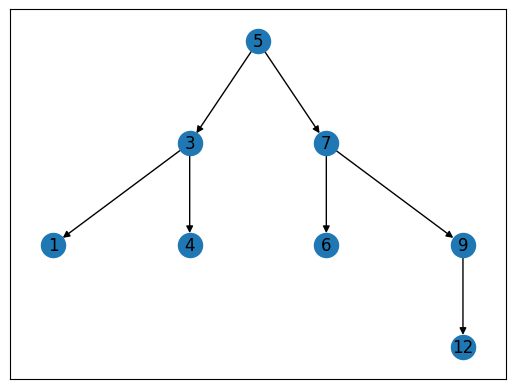

In [14]:
g = tree.to_nx()
pos = graphviz_layout(g, prog="dot")
nx.draw_networkx(g, labels=nx.get_node_attributes(g, "data"), pos=pos)

In [34]:
class Codec1:
    def serialize(root):
        """Encodes a tree to a single string."""

        def preorder(node: Node):
            if node is None:
                return []
            return [str(node.data)] + preorder(node.left) + preorder(node.right)

        return ",".join(preorder(root))

    def deserialize(data):
        """Decodes your encoded data to tree."""
        if not data:
            return None

        vals = list(map(int, data.split(",")))

        def build(preorder):
            if not preorder:
                return None

            root_val = preorder[0]
            root = Node(root_val)

            # Partition: left < root < right
            i = 1
            while i < len(preorder) and preorder[i] < root_val:
                i += 1

            root.left = build(preorder[1:i])
            root.right = build(preorder[i:])

            return root

        tree = Tree()
        tree.root = build(vals)
        return tree

In [41]:
serialized = Codec1.serialize(tree.root)
serialized

'5,3,1,4,7,6,9,12'

In [42]:
ntree = Codec1.deserialize(serialized)
for n in ntree.iter():
    print(n)

-:12:-
-:9:+
-:6:-
+:7:+
-:4:-
-:1:-
+:3:+
+:5:+


In [44]:
class Codec2:
    def serialize(root):
        """Iterative preorder serialization"""
        if not root:
            return ""

        stack = [root]
        result = []

        while stack:
            node = stack.pop()
            result.append(str(node.data))

            # Right first, then left (stack is LIFO)
            if node.right is not None:
                stack.append(node.right)
            if node.left is not None:
                stack.append(node.left)

        return ",".join(result)

    def deserialize(data):
        """Iterative deserialization"""
        if not data:
            return None

        vals = list(map(int, data.split(",")))
        root = Node(vals[0])
        stack = [root]

        for val in vals[1:]:
            node = Node(val)

            if val < stack[-1].data:
                stack[-1].left = node
            else:
                # Pop until we find appropriate parent
                parent = stack[-1]
                while stack and val > stack[-1].data:
                    parent = stack.pop()
                parent.right = node

            stack.append(node)

        return root

In [45]:
serialized = Codec2.serialize(tree.root)
serialized

'5,3,1,4,7,6,9,12'

In [48]:
ntree = Tree()
ntree.root = Codec2.deserialize(serialized)
for n in ntree.iter():
    print(n)

-:12:-
-:9:+
-:6:-
+:7:+
-:4:-
-:1:-
+:3:+
+:5:+


In [49]:
class CodecAdvanced:
    def serialize(root):
        """Binary serialization - most compact"""

        def preorder(node):
            if node is None:
                return b""
            # Convert value to 2 bytes (since 0 <= val <= 10000)
            val_bytes = node.data.to_bytes(2, byteorder="big")
            return val_bytes + preorder(node.left) + preorder(node.right)

        return preorder(root)

    def deserialize(data):
        """Binary deserialization"""
        if not data:
            return None

        def build(offset, lower, upper):
            if offset >= len(data):
                return None, offset

            val = int.from_bytes(data[offset : offset + 2], byteorder="big")
            if val < lower or val > upper:
                return None, offset

            root = Node(val)
            offset += 2

            root.left, offset = build(offset, lower, val)
            root.right, offset = build(offset, val, upper)

            return root, offset

        root, _ = build(0, float("-inf"), float("inf"))
        return root

In [50]:
serialized = CodecAdvanced.serialize(tree.root)
serialized

b'\x00\x05\x00\x03\x00\x01\x00\x04\x00\x07\x00\x06\x00\t\x00\x0c'

In [51]:
ntree = Tree()
ntree.root = CodecAdvanced.deserialize(serialized)
for n in ntree.iter():
    print(n)

-:12:-
-:9:+
-:6:-
+:7:+
-:4:-
-:1:-
+:3:+
+:5:+


In [64]:
import json


class JSONCodec:
    def serialize(root):
        def to_dict(node):
            if node is None:
                return None
            return {
                "val": node.data,
                "left": to_dict(node.left),
                "right": to_dict(node.right),
            }

        return json.dumps(to_dict(root))

    def deserialize(data):
        def from_dict(d):
            if d is None:
                return None
            node = Node(d["val"])
            node.left = from_dict(d["left"])
            node.right = from_dict(d["right"])
            return node

        return from_dict(json.loads(data))

In [66]:
tree = Tree()
tree.insert(5)
tree.insert(3)
tree.insert(1)
tree.insert(4)
tree.insert(7)
tree.insert(9)
tree.insert(6)
tree.insert(12)


serialized = JSONCodec.serialize(tree.root)
serialized

'{"val": 5, "left": {"val": 3, "left": {"val": 1, "left": null, "right": null}, "right": {"val": 4, "left": null, "right": null}}, "right": {"val": 7, "left": {"val": 6, "left": null, "right": null}, "right": {"val": 9, "left": null, "right": {"val": 12, "left": null, "right": null}}}}'

In [68]:
ntree = Tree()
ntree.root = JSONCodec.deserialize(serialized)
for n in ntree.iter():
    print(n)

-:12:-
-:9:+
-:6:-
+:7:+
-:4:-
-:1:-
+:3:+
+:5:+


In [67]:
g = ntree.to_nx()
pos = graphviz_layout(g, prog="dot")
nx.draw_networkx(g, labels=nx.get_node_attributes(g, "data"), pos=pos)

ValueError: None cannot be a node

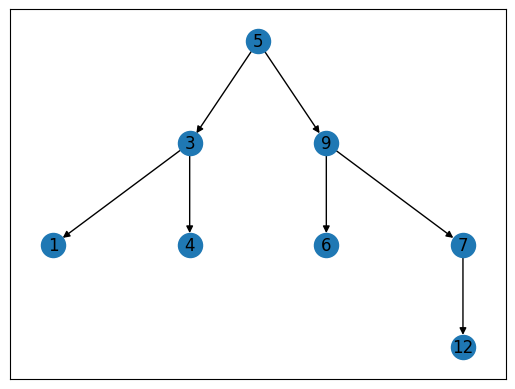

In [7]:
new_tree = deepcopy(tree)
n1 = new_tree.root.right
n2 = new_tree.root.right.right
n1.data, n2.data = n2.data, n1.data
g = new_tree.to_nx()
pos = graphviz_layout(g, prog="dot")
nx.draw_networkx(g, labels=nx.get_node_attributes(g, "data"), pos=pos)

In [8]:
new_tree.inorder()

1
3
4
5
6
9
7
12


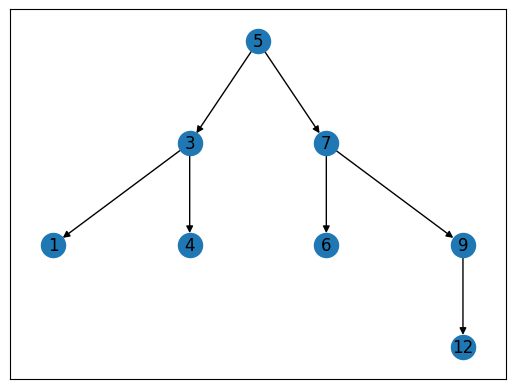

In [9]:
def recoverTree(root):
    # Step 1: Collect inorder traversal
    nodes = []
    values = []

    def inorder(node):
        if not node:
            return
        inorder(node.left)
        nodes.append(node)
        values.append(node.data)
        inorder(node.right)

    inorder(root)

    # Step 2: Sort values
    values.sort()

    # Step 3: Assign sorted values back to nodes
    for i in range(len(nodes)):
        nodes[i].data = values[i]


recoverTree(new_tree.root)

g = new_tree.to_nx()
pos = graphviz_layout(g, prog="dot")
nx.draw_networkx(g, labels=nx.get_node_attributes(g, "data"), pos=pos)

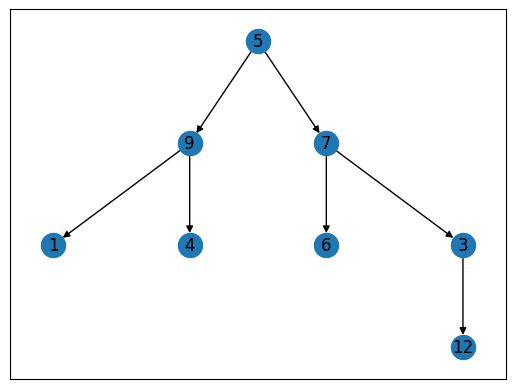

In [10]:
invalid_tree = deepcopy(tree)
n1 = invalid_tree.root.left
n2 = invalid_tree.root.right.right
n1.data, n2.data = n2.data, n1.data

g = invalid_tree.to_nx()
pos = graphviz_layout(g, prog="dot")
nx.draw_networkx(g, labels=nx.get_node_attributes(g, "data"), pos=pos)

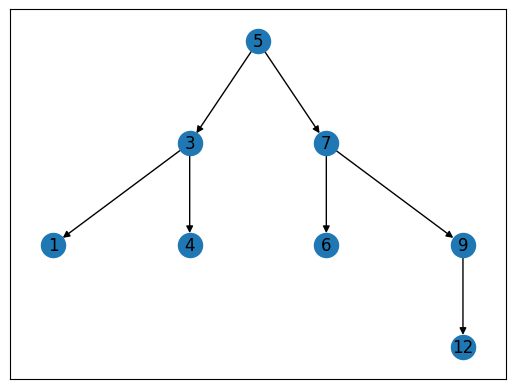

In [11]:
def recoverTree(root):
    # Find the two swapped nodes
    first = second = None
    prev = Node(data=float("-inf"))

    def inorder(node):
        nonlocal first, second, prev

        if not node:
            return

        inorder(node.left)

        # Detect anomaly: current < previous
        if node.data < prev.data:
            if not first:
                first = prev  # First anomaly
            second = node  # Second anomaly (could be adjacent case)

        prev = node

        inorder(node.right)

    inorder(root)

    # Swap values
    first.data, second.data = second.data, first.data


recoverTree(invalid_tree.root)

g = invalid_tree.to_nx()
pos = graphviz_layout(g, prog="dot")
nx.draw_networkx(g, labels=nx.get_node_attributes(g, "data"), pos=pos)

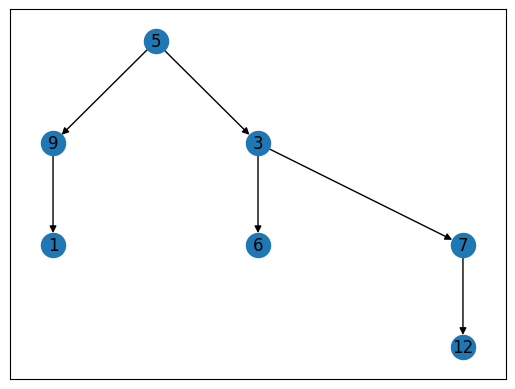

In [12]:
def recoverTree(root):
    first = second = None
    prev = Node(float("-inf"))
    current = root

    while current:
        if current.left is None:
            # Process current
            if current.data < prev.data:
                if not first:
                    first = prev
                second = current
            prev = current
            current = current.right
        else:
            # Find inorder predecessor
            predecessor = current.left
            while predecessor.right and predecessor.right != current:
                predecessor = predecessor.right

            if predecessor.right is None:
                # Create thread
                predecessor.right = current
                current = current.left
            else:
                # Break thread
                predecessor.right = None
                # Process current
                if current.data < prev.data:
                    if not first:
                        first = prev
                    second = current
                prev = current
                current = current.right

    # Swap values
    first.data, second.data = second.data, first.data


invalid_tree = deepcopy(tree)
n1 = invalid_tree.root.left
n2 = invalid_tree.root.right.right
n1.data, n2.data = n2.data, n1.data

recoverTree(root=invalid_tree.root)

g = invalid_tree.to_nx()
pos = graphviz_layout(g, prog="dot")
nx.draw_networkx(g, labels=nx.get_node_attributes(g, "data"), pos=pos)